In [1]:
import sys
!{sys.executable} -m pip install scikit-learn --break-system-packages


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [3]:
from sklearn.impute import SimpleImputer

In [4]:
import sys
!{sys.executable} -m pip install gdown --break-system-packages


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


In [5]:
import gdown

file_id = '1OOlNjO_zgh-mG97RyQtgDrWotz3XSOGU'

gdown.download(
    f'https://drive.google.com/uc?id={file_id}',
    'heart_2022_with_nans.csv',
    quiet=False
)

df = pd.read_csv('heart_2022_with_nans.csv')

Downloading...
From (original): https://drive.google.com/uc?id=1OOlNjO_zgh-mG97RyQtgDrWotz3XSOGU
From (redirected): https://drive.google.com/uc?id=1OOlNjO_zgh-mG97RyQtgDrWotz3XSOGU&confirm=t&uuid=7c5cdadd-245e-4f45-a8a1-26be63be62bf
To: /Users/savv/Library/Containers/net.whatsapp.WhatsApp/Data/tmp/documents/65613F0D-8800-4661-84EF-3BA5C73C373A/heart_2022_with_nans.csv
100%|██████████| 140M/140M [00:17<00:00, 7.89MB/s] 


In [6]:
import pandas as pd
non_penyakit = [
    "State",
    "Sex",
    "LastCheckupTime",
    "PhysicalActivities",
    "SleepHours",
    "RemovedTeeth",
    "SmokerStatus",
    "ECigaretteUsage",
    "ChestScan",
    "RaceEthnicityCategory",
    "AgeCategory",
    "HeightInMeters",
    "WeightInKilograms",
    "BMI",
    "AlcoholDrinkers",
    "HIVTesting",
    "FluVaxLast12",
    "PneumoVaxEver",
    "TetanusLast10Tdap",
    "HighRiskLastYear",
    "PhysicalHealthDays",
    "MentalHealthDays",
    "DifficultyWalking",
    "GeneralHealth"
]

df = df[non_penyakit]
df.head()

,State,Sex,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,SmokerStatus,ECigaretteUsage,ChestScan,RaceEthnicityCategory,...,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,PhysicalHealthDays,MentalHealthDays,DifficultyWalking,GeneralHealth
0,Alabama,Female,Within past year (anytime less than 12 months ...,No,8.0,NaN,Never smoked,Not at all (right now),No,"White only, Non-Hispanic",...,No,No,Yes,No,"Yes, received tetanus shot but not sure what type",No,0.0,0.0,No,Very good
1,Alabama,Female,NaN,No,6.0,NaN,Never smoked,Never used e-cigarettes in my entire life,No,"White only, Non-Hispanic",...,No,No,No,No,"No, did not receive any tetanus shot in the pa...",No,0.0,0.0,No,Excellent
2,Alabama,Female,Within past year (anytime less than 12 months ...,Yes,5.0,NaN,Never smoked,Never used e-cigarettes in my entire life,No,"White only, Non-Hispanic",...,No,No,No,No,NaN,No,2.0,3.0,No,Very good
3,Alabama,Female,Within past year (anytime less than 12 months ...,Yes,7.0,NaN,Current smoker - now smokes some days,Never used e-cigarettes in my entire life,Yes,"White only, Non-Hispanic",...,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,0.0,0.0,No,Excellent
4,Alabama,Female,Within past year (anytime less than 12 months ...,Yes,9.0,NaN,Never smoked,Never used e-cigarettes in my entire life,Yes,"White only, Non-Hispanic",...,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,2.0,0.0,No,Fair


In [7]:
print(df.columns)

Index(['State', 'Sex', 'LastCheckupTime', 'PhysicalActivities', 'SleepHours',
       'RemovedTeeth', 'SmokerStatus', 'ECigaretteUsage', 'ChestScan',
       'RaceEthnicityCategory', 'AgeCategory', 'HeightInMeters',
       'WeightInKilograms', 'BMI', 'AlcoholDrinkers', 'HIVTesting',
       'FluVaxLast12', 'PneumoVaxEver', 'TetanusLast10Tdap',
       'HighRiskLastYear', 'PhysicalHealthDays', 'MentalHealthDays',
       'DifficultyWalking', 'GeneralHealth'],
      dtype='object')


In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445132 entries, 0 to 445131
Data columns (total 24 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   State                  445132 non-null  object 
 1   Sex                    445132 non-null  object 
 2   LastCheckupTime        436824 non-null  object 
 3   PhysicalActivities     444039 non-null  object 
 4   SleepHours             439679 non-null  float64
 5   RemovedTeeth           433772 non-null  object 
 6   SmokerStatus           409670 non-null  object 
 7   ECigaretteUsage        409472 non-null  object 
 8   ChestScan              389086 non-null  object 
 9   RaceEthnicityCategory  431075 non-null  object 
 10  AgeCategory            436053 non-null  object 
 11  HeightInMeters         416480 non-null  float64
 12  WeightInKilograms      403054 non-null  float64
 13  BMI                    396326 non-null  float64
 14  AlcoholDrinkers        398558 non-nu

In [9]:
df.describe()

,SleepHours,HeightInMeters,WeightInKilograms,BMI,PhysicalHealthDays,MentalHealthDays
count,439679.000000,416480.000000,403054.000000,396326.000000,434205.000000,436065.000000
mean,7.022983,1.702691,83.074470,28.529842,4.347919,4.382649
std,1.502425,0.107177,21.448173,6.554889,8.688912,8.387475
min,1.000000,0.910000,22.680000,12.020000,0.000000,0.000000
25%,6.000000,1.630000,68.040000,24.130000,0.000000,0.000000
50%,7.000000,1.700000,80.740000,27.440000,0.000000,0.000000
75%,8.000000,1.780000,95.250000,31.750000,3.000000,5.000000
max,24.000000,2.410000,292.570000,99.640000,30.000000,30.000000


In [10]:
target_col = 'GeneralHealth'
feature_cols = [c for c in df.columns if c != target_col]

numeric_feature_cols = df[feature_cols].select_dtypes(include=np.number).columns

summary = df[numeric_feature_cols].agg(['mean','std','min','max']).T
summary['skewness'] = df[numeric_feature_cols].skew()
summary = summary.round(3)
print(summary.to_string())

                      mean     std    min     max  skewness
SleepHours           7.023   1.502   1.00   24.00     0.765
HeightInMeters       1.703   0.107   0.91    2.41     0.029
WeightInKilograms   83.074  21.448  22.68  292.57     1.076
BMI                 28.530   6.555  12.02   99.64     1.388
PhysicalHealthDays   4.348   8.689   0.00   30.00     2.180
MentalHealthDays     4.383   8.387   0.00   30.00     2.123


Missvalue dan sparsity

In [11]:
# Missing value
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Percent": missing_percent
})

missing_df[missing_df["Missing Count"] > 0]

,Missing Count,Percent
TetanusLast10Tdap,82516,18.537423
PneumoVaxEver,77040,17.307226
HIVTesting,66127,14.855593
ChestScan,56046,12.590872
HighRiskLastYear,50623,11.372582
BMI,48806,10.964388
FluVaxLast12,47121,10.585849
AlcoholDrinkers,46574,10.462964
WeightInKilograms,42078,9.452926
ECigaretteUsage,35660,8.011107


In [12]:
sparsity = (df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100
print(f"Persentase sparsity data: {sparsity:.2f}%")

Persentase sparsity data: 6.66%


Duplikat

In [13]:
df.duplicated().sum()

np.int64(356)

Outlier

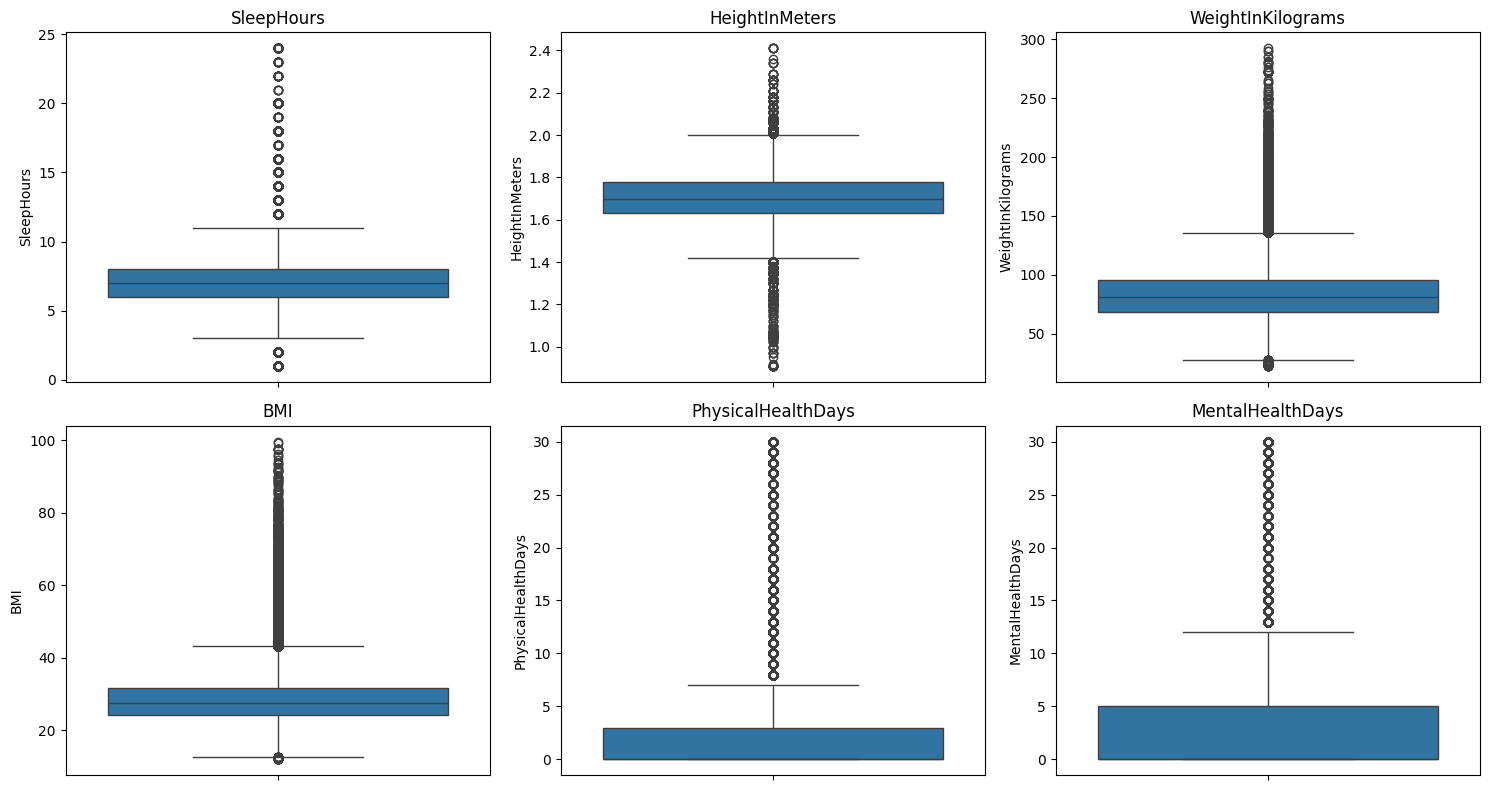

In [14]:
num_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,8))
for i, col in enumerate(num_cols[:6]):
    plt.subplot(2,3,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Cek Imbalance

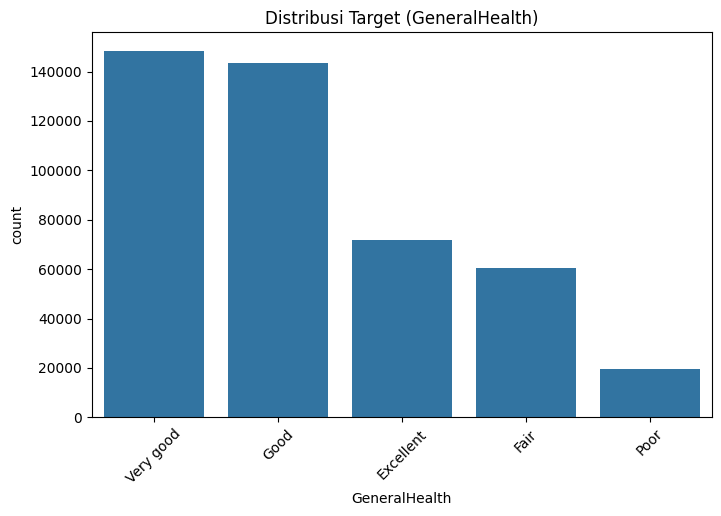

GeneralHealth
Very good    33.438304
Good         32.346700
Excellent    16.191146
Fair         13.577018
Poor          4.446832
Name: proportion, dtype: float64

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='GeneralHealth', order=df['GeneralHealth'].value_counts().index)
plt.title("Distribusi Target (GeneralHealth)")
plt.xticks(rotation=45)
plt.show()


df['GeneralHealth'].value_counts(normalize=True) * 100

Distribusi

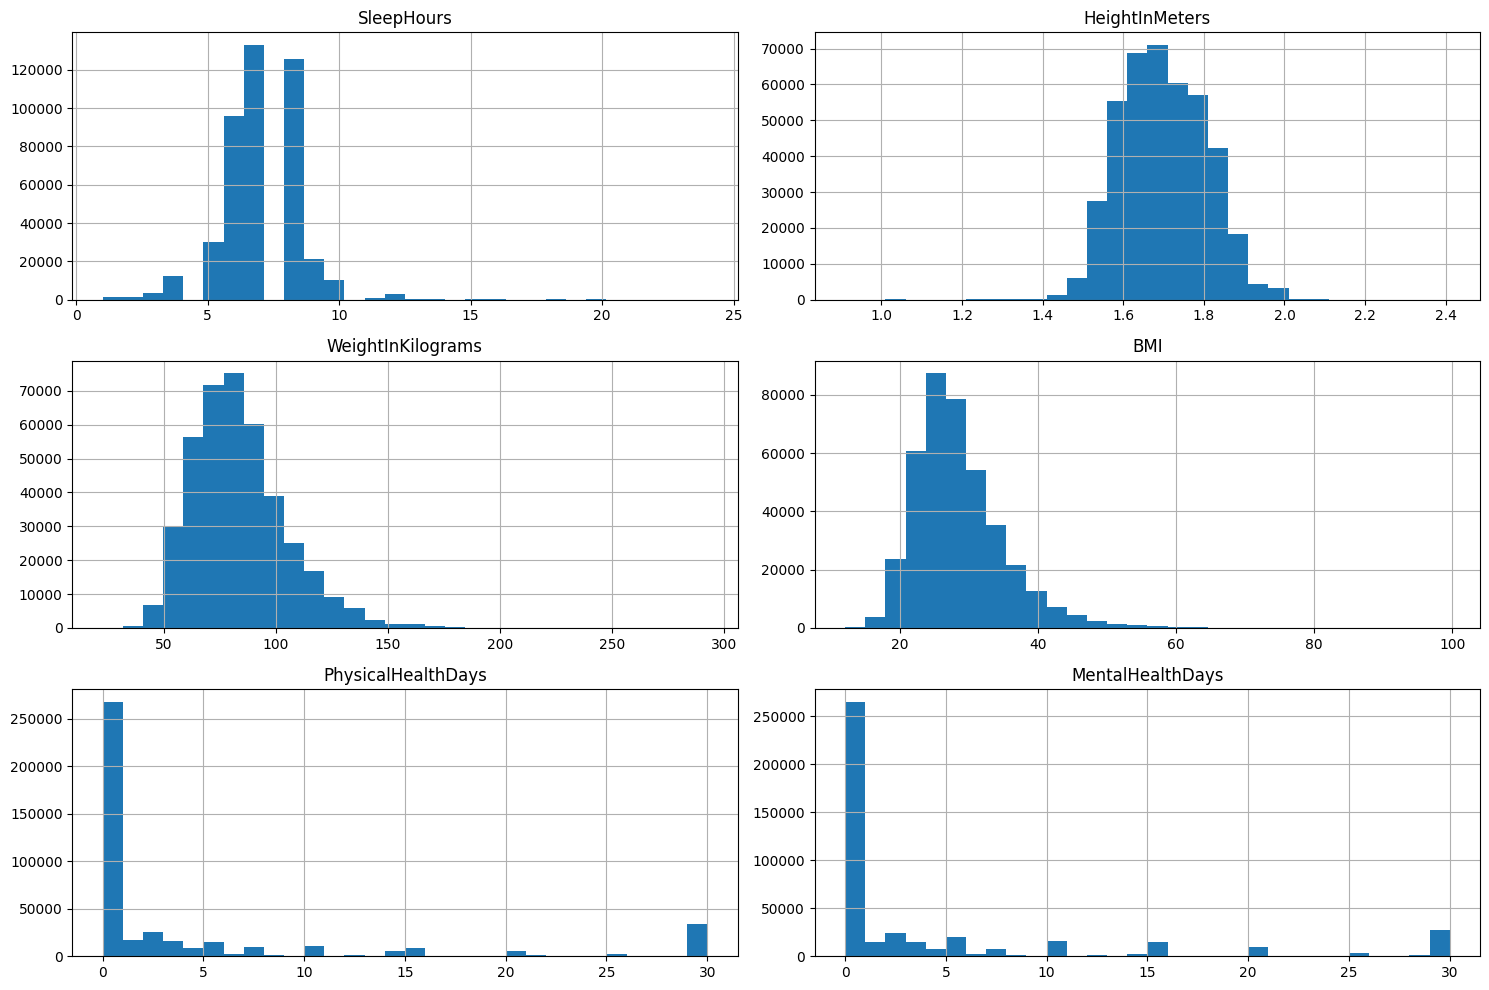

In [16]:
df.hist(figsize=(15,10), bins=30)
plt.tight_layout()
plt.show()

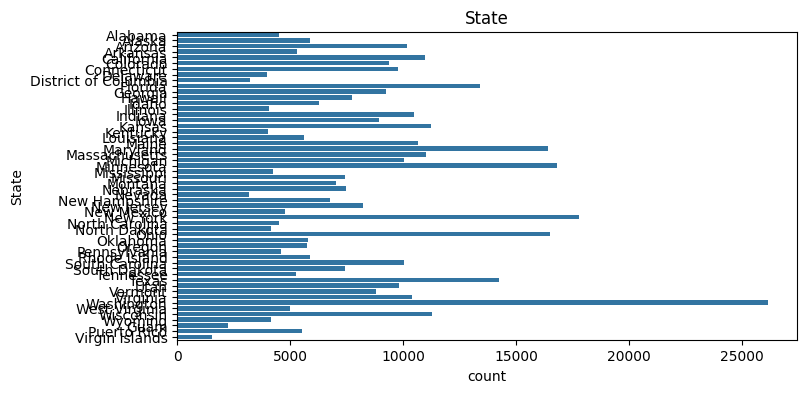

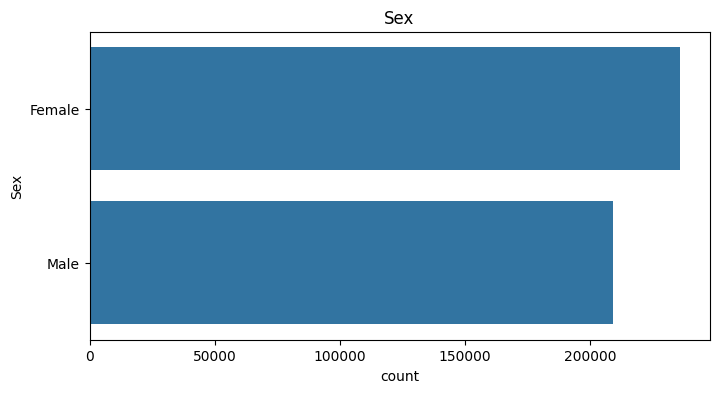

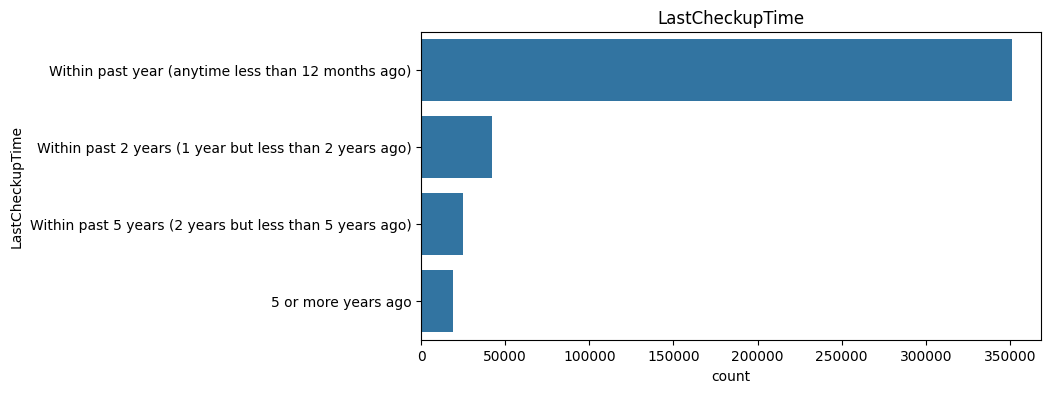

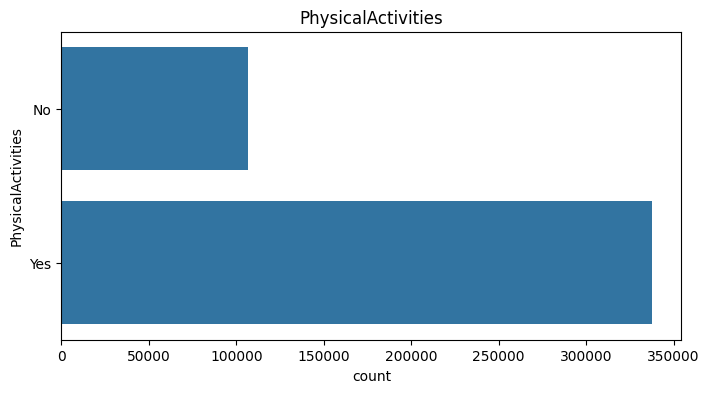

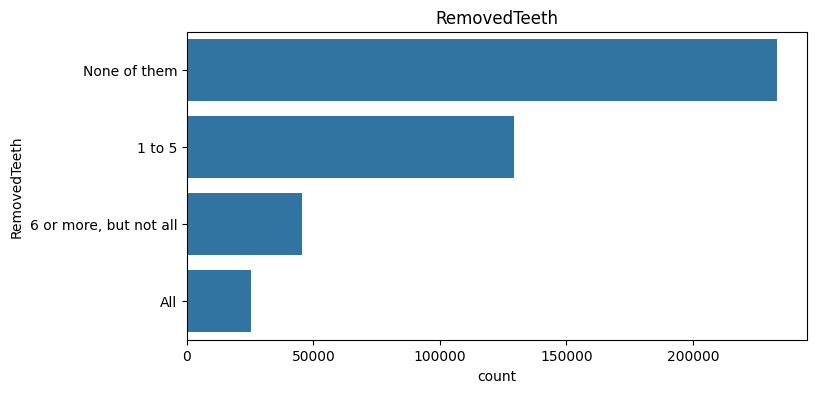

In [17]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols[:5]:
    plt.figure(figsize=(8,4))
    sns.countplot(y=df[col])
    plt.title(col)
    plt.show()

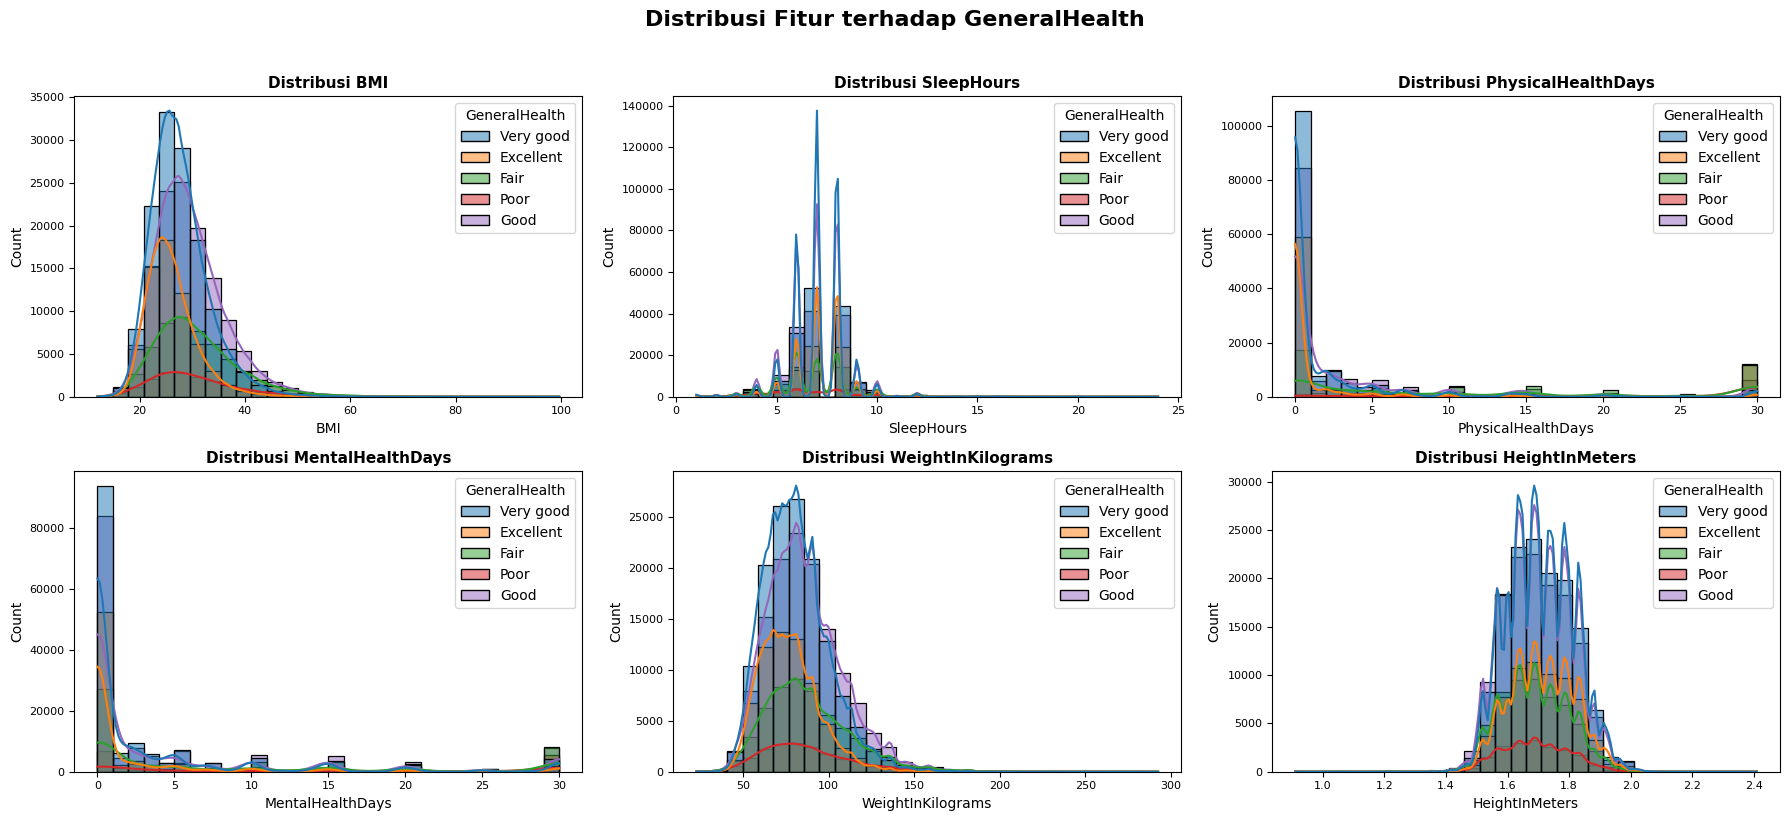

In [18]:
# Distribusi fitur berdasarkan GeneralHealth

import matplotlib.pyplot as plt
import seaborn as sns

# target
target_col = 'GeneralHealth'

# fitur numerik
feature_cols = [
    'BMI',
    'SleepHours',
    'PhysicalHealthDays',
    'MentalHealthDays',
    'WeightInKilograms',
    'HeightInMeters'
]

# jumlah kolom subplot
n_cols = 3
n_rows = (len(feature_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(18, n_rows * 4))

axes = axes.flatten()

# looping visualisasi
for i, col in enumerate(feature_cols):

    sns.histplot(
        data=df,
        x=col,
        hue=target_col,
        bins=30,
        kde=True,
        alpha=0.5,
        ax=axes[i]
    )

    axes[i].set_title(
        f'Distribusi {col}',
        fontsize=11,
        fontweight='bold'
    )

    axes[i].tick_params(labelsize=8)

# hapus subplot kosong
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# judul utama
plt.suptitle(
    'Distribusi Fitur terhadap GeneralHealth',
    fontsize=16,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

Korelasi

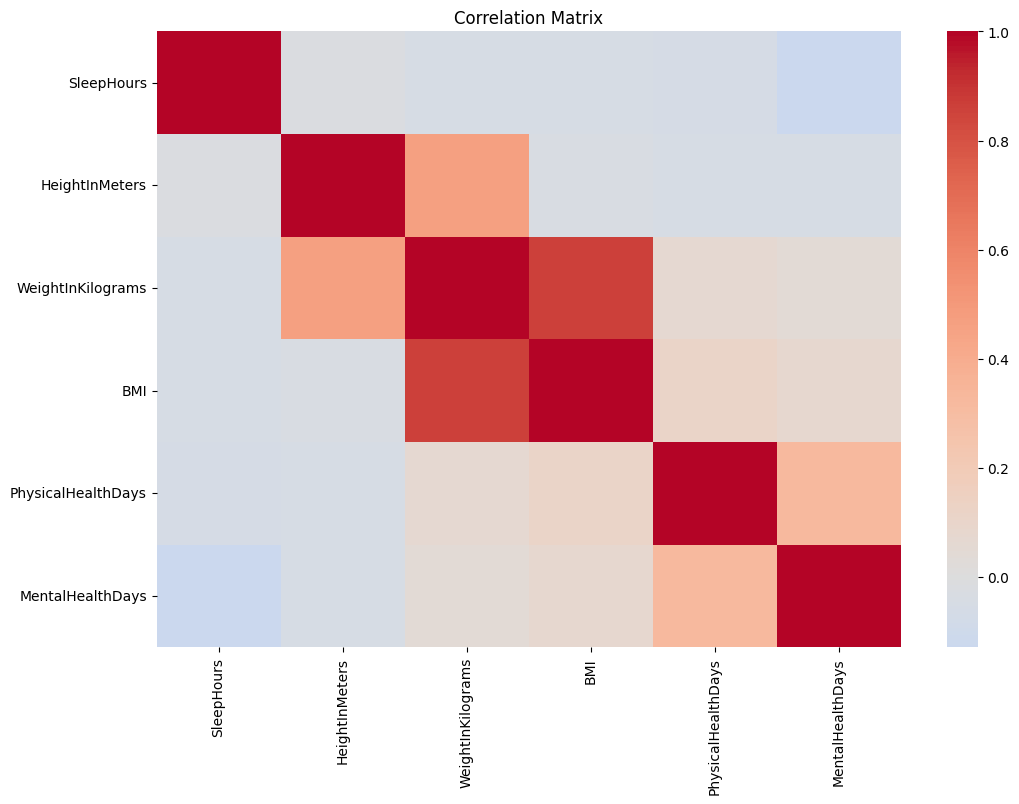

In [19]:
plt.figure(figsize=(12,8))
corr = df[num_cols].corr()

sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()

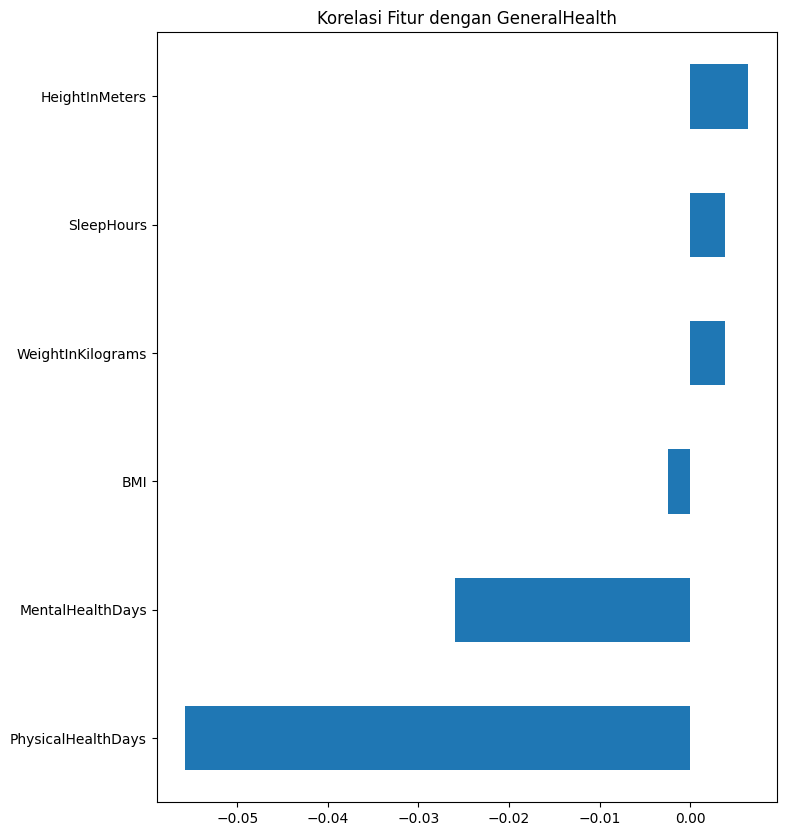

In [20]:
df_encoded = df.copy()

le = LabelEncoder()
df_encoded['GeneralHealth_enc'] = le.fit_transform(df_encoded['GeneralHealth'])

corr_target = df_encoded[num_cols].corrwith(df_encoded['GeneralHealth_enc']).sort_values()

plt.figure(figsize=(8,10))
corr_target.plot(kind='barh')
plt.title("Korelasi Fitur dengan GeneralHealth")
plt.show()

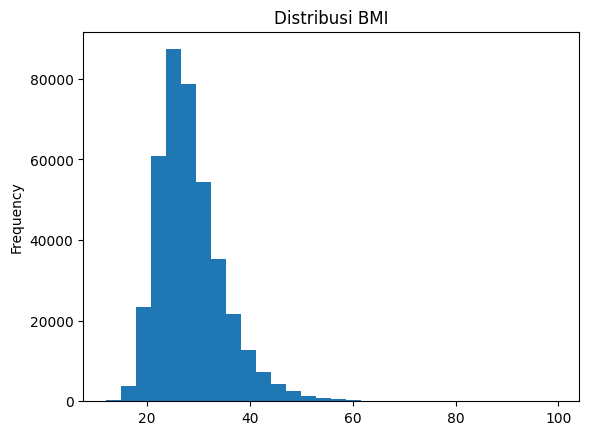

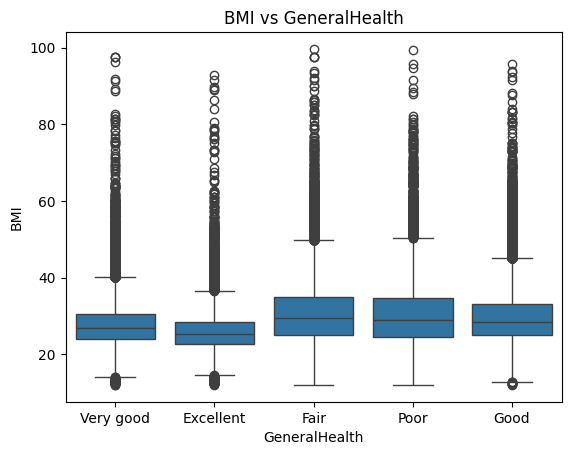

In [21]:
df['BMI'].plot(kind='hist', bins=30, title="Distribusi BMI")
plt.show()

sns.boxplot(x='GeneralHealth', y='BMI', data=df)
plt.title("BMI vs GeneralHealth")
plt.show()

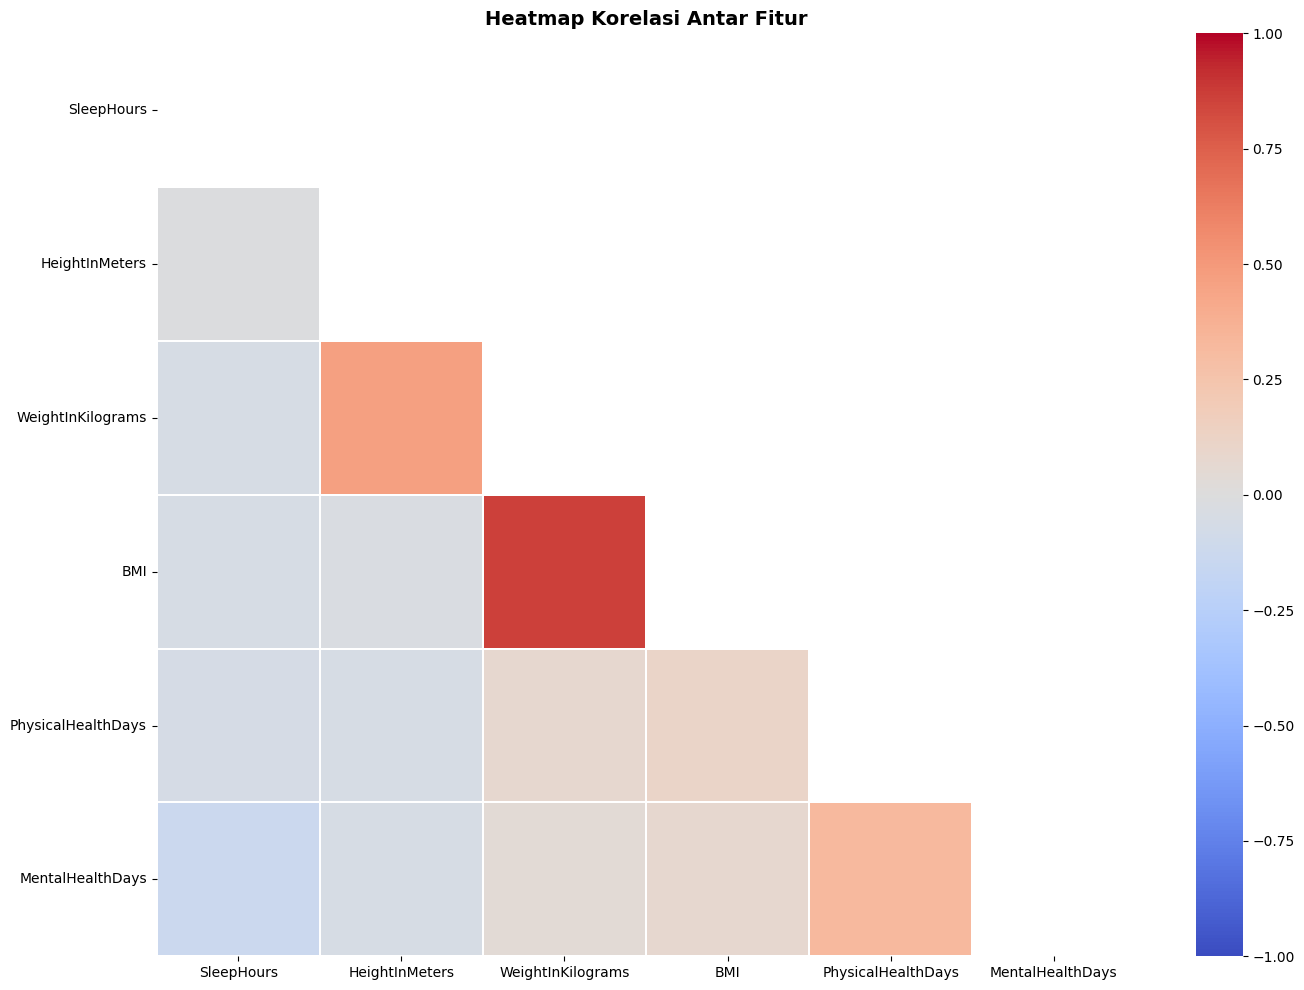

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


feature_cols = df.select_dtypes(include=np.number).columns


corr_matrix = df[feature_cols].corr()


mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# visualisasi
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=False,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.3
)

plt.title('Heatmap Korelasi Antar Fitur',
          fontsize=14,
          fontweight='bold')

plt.tight_layout()
plt.show()

# Preprocessing

### Drop Missing Value pada Target

In [23]:
print("Missing target:", df['GeneralHealth'].isnull().sum())

Missing target: 1198


In [24]:
df = df.dropna(subset=['GeneralHealth'])

In [25]:
print("Missing target after:", df['GeneralHealth'].isnull().sum())

Missing target after: 0


In [26]:
print("Shape dataset:", df.shape)

Shape dataset: (443934, 24)


## Handling Duplicate

In [27]:
print("Duplicate:", df.duplicated().sum())

Duplicate: 351


In [28]:
df = df.drop_duplicates()

In [29]:
print("Duplicate after:", df.duplicated().sum())

Duplicate after: 0


In [30]:
print("Shape dataset:", df.shape)

Shape dataset: (443583, 24)


## Split

In [31]:
from sklearn.model_selection import train_test_split

X = df.drop(columns='GeneralHealth')
y = df['GeneralHealth']

# Split train-test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (354866, 23)
X_test : (88717, 23)
y_train: (354866,)
y_test : (88717,)


## Handle Missing Value

### Numerik

In [32]:
from sklearn.impute import SimpleImputer
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
num_imputer = SimpleImputer(strategy='median')

X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])

X_test[num_cols] = num_imputer.transform(X_test[num_cols])

In [33]:
# Cek missing numerik
print("Missing numerik train:")
print(X_train[num_cols].isnull().sum())

print("\nMissing numerik test:")
print(X_test[num_cols].isnull().sum())

Missing numerik train:
SleepHours            0
HeightInMeters        0
WeightInKilograms     0
BMI                   0
PhysicalHealthDays    0
MentalHealthDays      0
dtype: int64

Missing numerik test:
SleepHours            0
HeightInMeters        0
WeightInKilograms     0
BMI                   0
PhysicalHealthDays    0
MentalHealthDays      0
dtype: int64


### Kategorikal

In [34]:
cat_cols = X_train.select_dtypes(include=['object']).columns

cat_imputer = SimpleImputer(
    strategy='constant',
    fill_value='Unknown'
)

# Fit train
X_train[cat_cols] = cat_imputer.fit_transform(
    X_train[cat_cols]
)

In [35]:
X_test[cat_cols] = cat_imputer.transform(
    X_test[cat_cols]
)

# Cek missing kategorikal
print("Missing kategorikal train:")
print(X_train[cat_cols].isnull().sum())

print("\nMissing kategorikal test:")
print(X_test[cat_cols].isnull().sum())

Missing kategorikal train:
State                    0
Sex                      0
LastCheckupTime          0
PhysicalActivities       0
RemovedTeeth             0
SmokerStatus             0
ECigaretteUsage          0
ChestScan                0
RaceEthnicityCategory    0
AgeCategory              0
AlcoholDrinkers          0
HIVTesting               0
FluVaxLast12             0
PneumoVaxEver            0
TetanusLast10Tdap        0
HighRiskLastYear         0
DifficultyWalking        0
dtype: int64

Missing kategorikal test:
State                    0
Sex                      0
LastCheckupTime          0
PhysicalActivities       0
RemovedTeeth             0
SmokerStatus             0
ECigaretteUsage          0
ChestScan                0
RaceEthnicityCategory    0
AgeCategory              0
AlcoholDrinkers          0
HIVTesting               0
FluVaxLast12             0
PneumoVaxEver            0
TetanusLast10Tdap        0
HighRiskLastYear         0
DifficultyWalking        0
dtype: int64


## Feature Engineering

### Encoding

In [36]:
from sklearn.preprocessing import OrdinalEncoder

binary_cols = [
    'PhysicalActivities', 'ChestScan', 'AlcoholDrinkers',
    'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver',
    'DifficultyWalking', 'HighRiskLastYear'
]

binary_cols = [c for c in binary_cols if c in X_train.columns]

binary_map = {
    'Yes': 1,
    'No': 0,
    'Unknown': -1
}

for col in binary_cols:
    X_train[col] = X_train[col].map(binary_map)
    X_test[col]  = X_test[col].map(binary_map)

print(X_train[binary_cols].head())
print(X_train[binary_cols].head())

        PhysicalActivities  ChestScan  AlcoholDrinkers  HIVTesting  \
186692                   1          0                1           0   
326706                   0          1                1           0   
102047                   1          0                1           0   
296183                   0          0                0           1   
314150                   1          0                0           0   

        FluVaxLast12  PneumoVaxEver  DifficultyWalking  HighRiskLastYear  
186692             0              0                  0                 0  
326706             1              1                  1                 0  
102047             0              1                  0                 0  
296183             0              0                  0                 0  
314150             1              0                  0                 0  
        PhysicalActivities  ChestScan  AlcoholDrinkers  HIVTesting  \
186692                   1          0                1     

In [37]:
sex_map = {
    'Female': 0,
    'Male': 1
}

X_train['Sex'] = X_train['Sex'].map(sex_map)
X_test['Sex']  = X_test['Sex'].map(sex_map)

print(X_train['Sex'].head())

186692    1
326706    0
102047    0
296183    0
314150    0
Name: Sex, dtype: int64


In [38]:
from sklearn.preprocessing import OneHotEncoder

nominal_cols = ['State', 'RaceEthnicityCategory', 'TetanusLast10Tdap']
nominal_cols = [c for c in nominal_cols if c in X_train.columns]

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')

ohe_train = ohe.fit_transform(X_train[nominal_cols])
ohe_test  = ohe.transform(X_test[nominal_cols])

ohe_cols = ohe.get_feature_names_out(nominal_cols)

ohe_train_df = pd.DataFrame(ohe_train, columns=ohe_cols, index=X_train.index)
ohe_test_df  = pd.DataFrame(ohe_test,  columns=ohe_cols, index=X_test.index)

X_train = X_train.drop(columns=nominal_cols)
X_test  = X_test.drop(columns=nominal_cols)

X_train = pd.concat([X_train, ohe_train_df], axis=1)
X_test  = pd.concat([X_test,  ohe_test_df],  axis=1)

print(ohe_train_df.head())

        State_Alaska  State_Arizona  State_Arkansas  State_California  \
186692           0.0            0.0             0.0               0.0   
326706           0.0            0.0             0.0               0.0   
102047           0.0            0.0             0.0               0.0   
296183           0.0            0.0             0.0               0.0   
314150           0.0            0.0             0.0               0.0   

        State_Colorado  State_Connecticut  State_Delaware  \
186692             0.0                0.0             0.0   
326706             0.0                0.0             0.0   
102047             0.0                0.0             0.0   
296183             0.0                0.0             0.0   
314150             0.0                0.0             0.0   

        State_District of Columbia  State_Florida  State_Georgia  ...  \
186692                         0.0            0.0            0.0  ...   
326706                         0.0            0.

In [39]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_cols = [
    'SmokerStatus',
    'ECigaretteUsage',
    'LastCheckupTime',
    'RemovedTeeth',
    'AgeCategory'
]

ordinal_cols = [c for c in ordinal_cols if c in X_train.columns]

ord_encoder2 = OrdinalEncoder(
    categories=[
        ['Never smoked', 'Former smoker', 'Current smoker - some days', 'Current smoker - every day'],

        ['Never used e-cigarettes in my entire life', 'Not at all (right now)',
         'Use them some days', 'Use them every day'],

        ['5 or more years ago',
         'Within past 5 years (2 years but less than 5 years ago)',
         'Within past 2 years (1 year but less than 2 years ago)',
         'Within past year (anytime less than 12 months ago)'],

        ['None of them', '1 to 5', '6 or more, but not all', 'All'],

        ['Age 18 to 24', 'Age 25 to 29', 'Age 30 to 34',
         'Age 35 to 39', 'Age 40 to 44', 'Age 45 to 49',
         'Age 50 to 54', 'Age 55 to 59', 'Age 60 to 64',
         'Age 65 to 69', 'Age 70 to 74', 'Age 75 to 79',
         'Age 80 or older']
    ],
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

X_train[ordinal_cols] = ord_encoder2.fit_transform(X_train[ordinal_cols])
X_test[ordinal_cols]  = ord_encoder2.transform(X_test[ordinal_cols])

print(X_train[ordinal_cols].head())

        SmokerStatus  ECigaretteUsage  LastCheckupTime  RemovedTeeth  \
186692           0.0              0.0              3.0           0.0   
326706           1.0              0.0              3.0           1.0   
102047           0.0              0.0              3.0           0.0   
296183           0.0              0.0              3.0           0.0   
314150           0.0              0.0              3.0           0.0   

        AgeCategory  
186692          1.0  
326706          9.0  
102047          9.0  
296183          2.0  
314150          3.0  


In [40]:
# Encoding target
target_order = [['Poor', 'Fair', 'Good', 'Very good', 'Excellent']]

target_encoder = OrdinalEncoder(categories=target_order)

y_train = target_encoder.fit_transform(y_train.values.reshape(-1, 1)).ravel().astype(int)
y_test  = target_encoder.transform(y_test.values.reshape(-1, 1)).ravel().astype(int)

print(f"Mapping: {dict(zip(target_order[0], range(5)))}")

Mapping: {'Poor': 0, 'Fair': 1, 'Good': 2, 'Very good': 3, 'Excellent': 4}


### Scaling

In [41]:
scale_cols = [
    'SleepHours', 'HeightInMeters', 'WeightInKilograms',
    'BMI', 'PhysicalHealthDays', 'MentalHealthDays'
]
scale_cols = [c for c in scale_cols if c in X_train.columns]

In [42]:
df_before = X_train[scale_cols].copy()
skewed_cols = ['PhysicalHealthDays', 'MentalHealthDays']

for col in skewed_cols:
    X_train[col] = np.log1p(X_train[col])
    X_test[col]  = np.log1p(X_test[col])

In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols]  = scaler.transform(X_test[scale_cols])

print(X_train[scale_cols].describe().round(3))

       SleepHours  HeightInMeters  WeightInKilograms         BMI  \
count  354866.000      354866.000         354866.000  354866.000   
mean        0.000           0.000              0.000       0.000   
std         1.000           1.000              1.000       1.000   
min        -4.039          -7.645             -2.945      -2.643   
25%        -0.686          -0.700             -0.726      -0.646   
50%        -0.015          -0.025             -0.104      -0.157   
75%         0.655           0.747              0.428       0.418   
max        11.385           6.824             10.147      11.434   

       PhysicalHealthDays  MentalHealthDays  
count          354866.000        354866.000  
mean               -0.000            -0.000  
std                 1.000             1.000  
min                -0.670            -0.695  
25%                -0.670            -0.695  
50%                -0.670            -0.695  
75%                 0.521             0.678  
max                

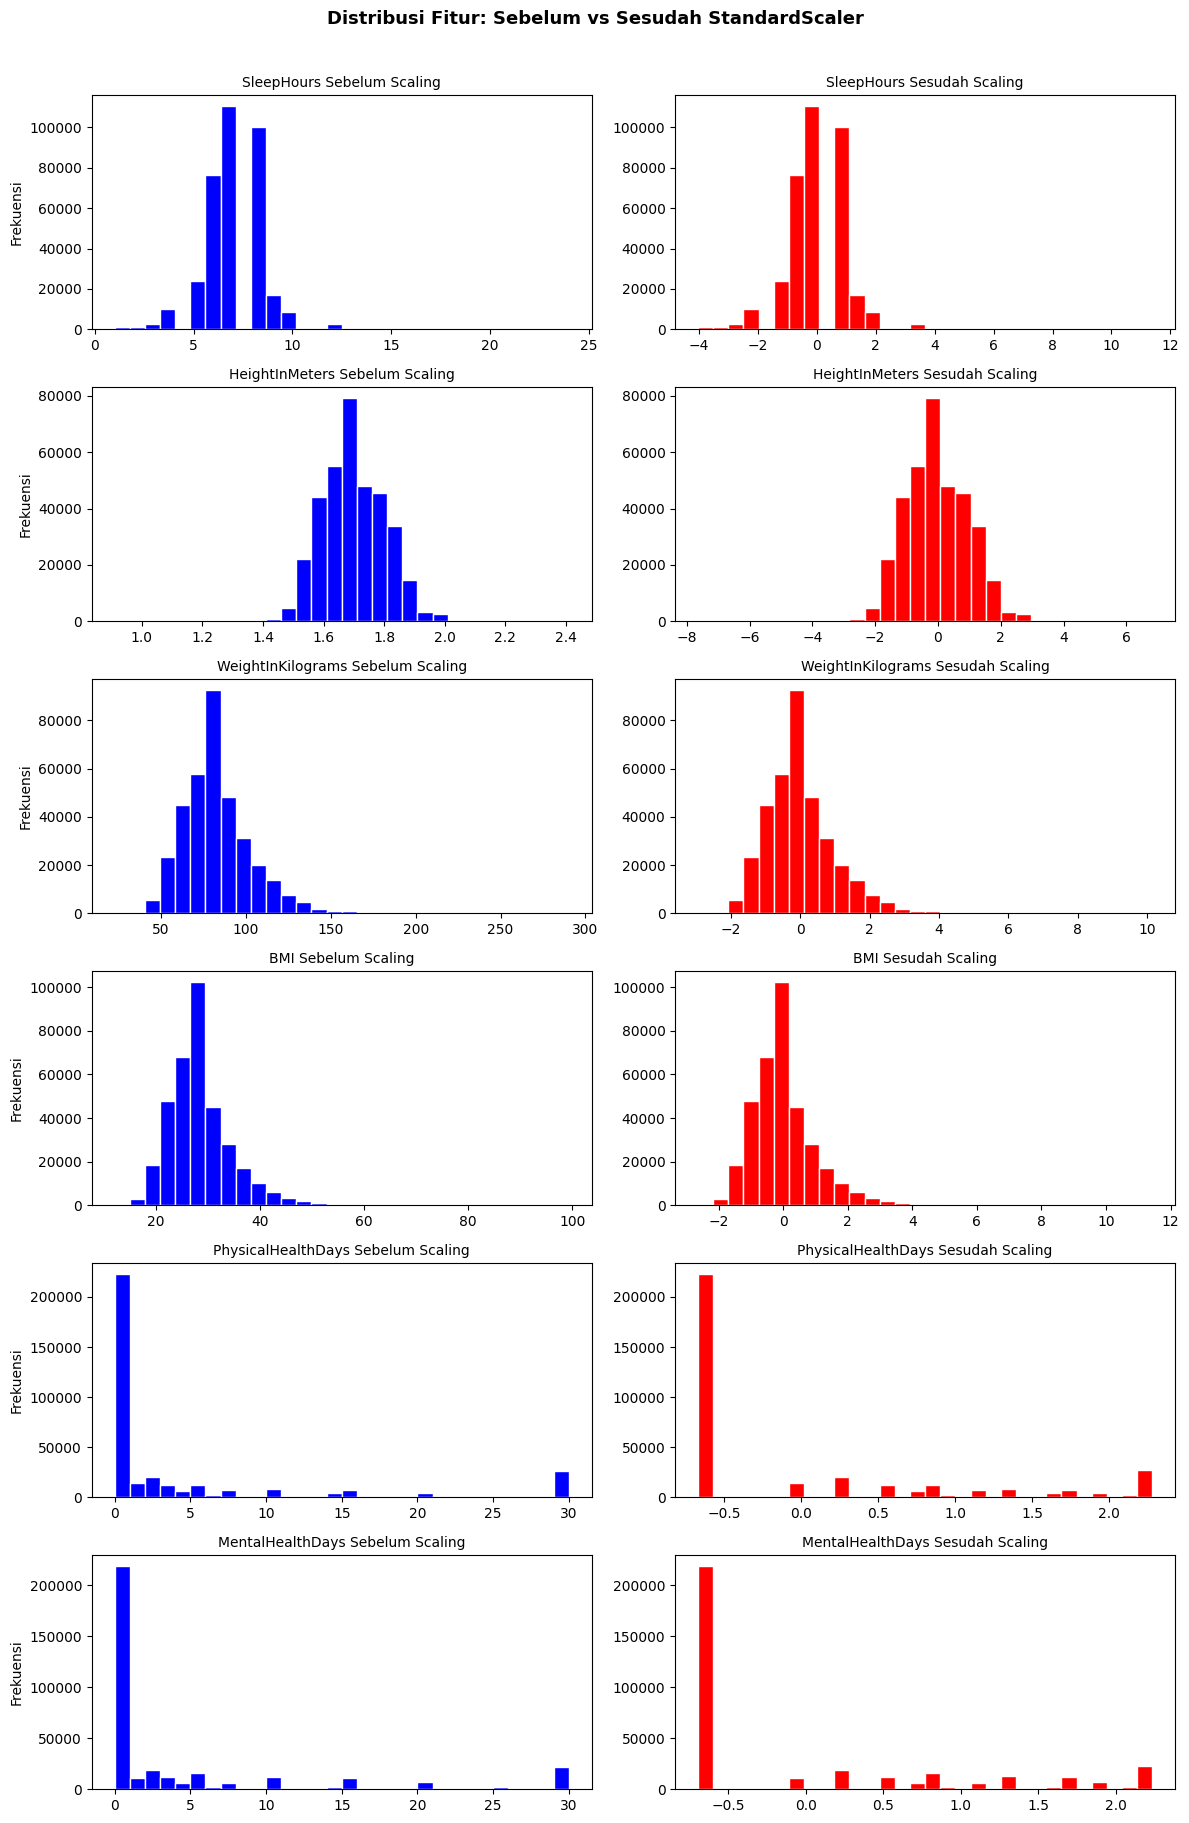

In [44]:
fig, axes = plt.subplots(len(scale_cols), 2, figsize=(12, len(scale_cols) * 3))

for i, col in enumerate(scale_cols):
    axes[i, 0].hist(df_before[col], bins=30, color='blue', edgecolor='white')
    axes[i, 0].set_title(f'{col} Sebelum Scaling', fontsize=10)
    axes[i, 0].set_ylabel('Frekuensi')

    axes[i, 1].hist(X_train[col], bins=30, color='red', edgecolor='white')
    axes[i, 1].set_title(f'{col} Sesudah Scaling', fontsize=10)

plt.suptitle('Distribusi Fitur: Sebelum vs Sesudah StandardScaler',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [45]:
# Cek total NaN train
print("NaN X_train:", X_train.isnull().sum().sum())

# Kolom yang masih ada NaN
nan_cols = X_train.columns[X_train.isnull().any()]

print("\nKolom yang masih mengandung NaN:")
print(X_train[nan_cols].isnull().sum())

NaN X_train: 0

Kolom yang masih mengandung NaN:
Series([], dtype: float64)


# SMOTE

In [46]:
import sys
!{sys.executable} -m pip install imbalanced-learn -q --break-system-packages

from imblearn.over_sampling import SMOTE
from collections import Counter

print("Distribusi kelas sebelum SMOTE:")
print(Counter(y_train))

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nDistribusi kelas setelah SMOTE:")
print(Counter(y_train_sm))


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Distribusi kelas sebelum SMOTE:
Counter({np.int64(3): 118612, np.int64(2): 114820, np.int64(4): 57425, np.int64(1): 48216, np.int64(0): 15793})

Distribusi kelas setelah SMOTE:
Counter({np.int64(3): 118612, np.int64(0): 118612, np.int64(2): 118612, np.int64(4): 118612, np.int64(1): 118612})


EDA Post-Processing

Visualisasi Distribusi Kelas setelah SMOTE

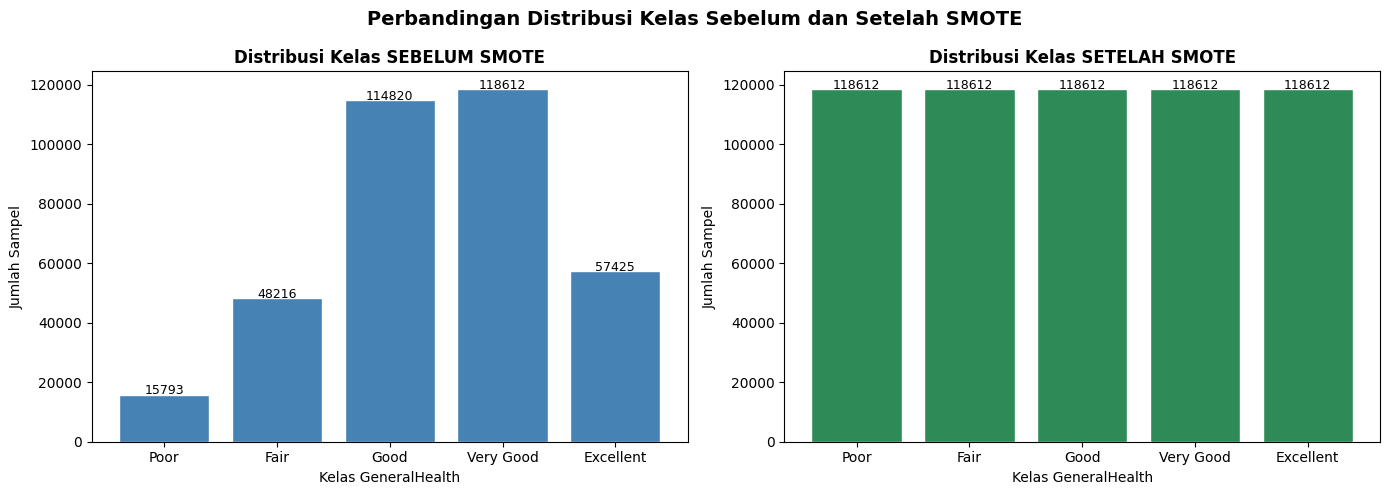


Ukuran X_train sebelum SMOTE : (354866, 82)
Ukuran X_train setelah SMOTE  : (593060, 82)


In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sebelum SMOTE
class_labels = ['Poor', 'Fair', 'Good', 'Very Good', 'Excellent']
before = Counter(y_train)
axes[0].bar(class_labels, [before[i] for i in range(5)], color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Kelas SEBELUM SMOTE', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')
axes[0].set_xlabel('Kelas GeneralHealth')
for i, v in enumerate([before[i] for i in range(5)]):
    axes[0].text(i, v + 100, str(v), ha='center', fontsize=9)

# Setelah SMOTE
after = Counter(y_train_sm)
axes[1].bar(class_labels, [after[i] for i in range(5)], color='seagreen', edgecolor='white')
axes[1].set_title('Distribusi Kelas SETELAH SMOTE', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Jumlah Sampel')
axes[1].set_xlabel('Kelas GeneralHealth')
for i, v in enumerate([after[i] for i in range(5)]):
    axes[1].text(i, v + 100, str(v), ha='center', fontsize=9)

plt.suptitle('Perbandingan Distribusi Kelas Sebelum dan Setelah SMOTE',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nUkuran X_train sebelum SMOTE : {X_train.shape}")
print(f"Ukuran X_train setelah SMOTE  : {X_train_sm.shape}")

In [48]:
df = df.drop(columns=['State'])

In [49]:
import sys
!{sys.executable} -m pip install catboost -q --break-system-packages


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


In [50]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [51]:
cat_model = CatBoostClassifier(
    iterations=800,
    learning_rate=0.1,
    depth=6,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    random_state=42,
    verbose=50
)
# Training
cat_model.fit(X_train, y_train)

0:	learn: 0.4217648	total: 110ms	remaining: 1m 27s
50:	learn: 0.4535543	total: 2.18s	remaining: 32s
100:	learn: 0.4592607	total: 4.12s	remaining: 28.5s
150:	learn: 0.4627606	total: 5.98s	remaining: 25.7s
200:	learn: 0.4649304	total: 7.78s	remaining: 23.2s
250:	learn: 0.4667480	total: 9.63s	remaining: 21.1s
300:	learn: 0.4686783	total: 11.5s	remaining: 19s
350:	learn: 0.4704395	total: 13.4s	remaining: 17.2s
400:	learn: 0.4723473	total: 15.3s	remaining: 15.2s
450:	learn: 0.4737619	total: 17.1s	remaining: 13.3s
500:	learn: 0.4752132	total: 19s	remaining: 11.3s
550:	learn: 0.4768420	total: 20.9s	remaining: 9.44s
600:	learn: 0.4781129	total: 22.8s	remaining: 7.55s
650:	learn: 0.4793809	total: 24.7s	remaining: 5.65s
700:	learn: 0.4808209	total: 26.8s	remaining: 3.78s
750:	learn: 0.4819988	total: 28.8s	remaining: 1.88s
799:	learn: 0.4830330	total: 30.6s	remaining: 0us


CatBoostClassifier(depth=6, eval_metric='Accuracy', iterations=800, learning_rate=0.1, loss_function='MultiClass', random_state=42, verbose=50)

In [53]:
# Prediksi
y_pred_cat = cat_model.predict(X_test)

In [55]:
acc = accuracy_score(y_test, y_pred_cat)

print("Accuracy:", acc)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_cat))

Accuracy: 0.4612982855597011

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.41      0.46      3948
           1       0.44      0.32      0.38     12054
           2       0.45      0.51      0.48     28705
           3       0.47      0.61      0.53     29653
           4       0.47      0.19      0.27     14357

    accuracy                           0.46     88717
   macro avg       0.47      0.41      0.42     88717
weighted avg       0.46      0.46      0.45     88717



In [56]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': cat_model.feature_importances_
})

feature_importance.sort_values(
    'Importance',
    ascending=False
).head(20)

,Feature,Importance
17,PhysicalHealthDays,19.639714
11,BMI,9.021591
19,DifficultyWalking,8.327101
18,MentalHealthDays,6.939782
8,AgeCategory,6.206839
4,RemovedTeeth,5.570071
7,ChestScan,4.238433
2,PhysicalActivities,4.235794
3,SleepHours,3.898701
10,WeightInKilograms,3.292278


# Baseline (Logistic Regresion)

In [57]:
from sklearn.linear_model import LogisticRegression

Inisialisasi Model

In [58]:
print(LogisticRegression)

<class 'sklearn.linear_model._logistic.LogisticRegression'>


In [59]:
import sklearn
print(sklearn.__version__)

1.8.0


In [60]:
log_reg = LogisticRegression(
    max_iter=200,
    solver='saga',
    n_jobs=-1
)

Training Model

In [61]:
log_reg.fit(X_train_sm, y_train_sm)

/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Prediksi

In [62]:
y_pred = log_reg.predict(X_test)

Evaluasi

In [63]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)
print("Accuracy Logistic Regression:", acc)

Accuracy Logistic Regression: 0.3678438179830247


Classification Report

In [64]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.31      0.76      0.44      3948
           1       0.29      0.32      0.31     12054
           2       0.44      0.28      0.34     28705
           3       0.46      0.31      0.37     29653
           4       0.31      0.60      0.41     14357

    accuracy                           0.37     88717
   macro avg       0.36      0.45      0.37     88717
weighted avg       0.40      0.37      0.36     88717



Confusion Matriks

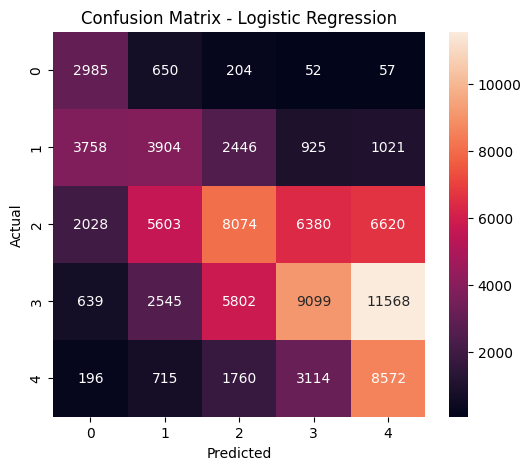

In [77]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

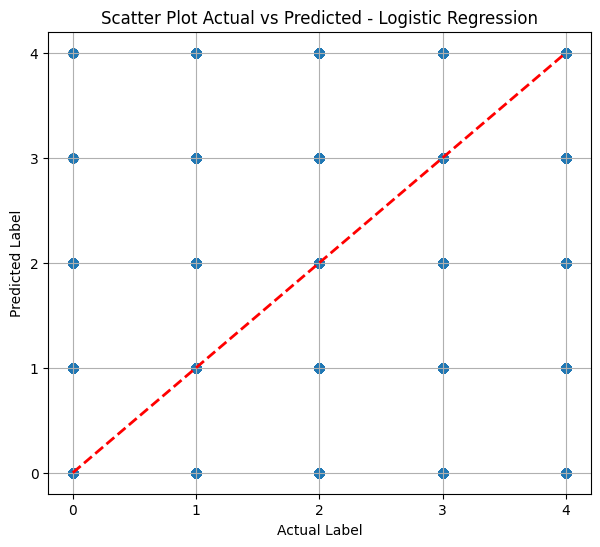

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.3
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Label")
plt.ylabel("Predicted Label")
plt.title("Scatter Plot Actual vs Predicted - Logistic Regression")

plt.xticks([0,1,2,3,4])
plt.yticks([0,1,2,3,4])

plt.grid(True)

plt.show()

# Random Forest

In [78]:
from sklearn.ensemble import RandomForestClassifier

Inisialisasi Model

In [68]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=1,
   # ← ini gantinya SMOTE
)



Training Model

In [69]:
rf.fit(X_train_sm, y_train_sm)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Prediksi

In [70]:
y_pred_rf = rf.predict(X_test)

Evaluasi

In [71]:
acc_rf = accuracy_score(y_test, y_pred_rf)
print("Accuracy Random Forest:", acc_rf)

Accuracy Random Forest: 0.43375001408974606


Classification Report

In [72]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.44      0.52      0.47      3948
           1       0.39      0.35      0.37     12054
           2       0.43      0.46      0.45     28705
           3       0.46      0.51      0.49     29653
           4       0.39      0.27      0.32     14357

    accuracy                           0.43     88717
   macro avg       0.42      0.42      0.42     88717
weighted avg       0.43      0.43      0.43     88717



Confusion Matrix

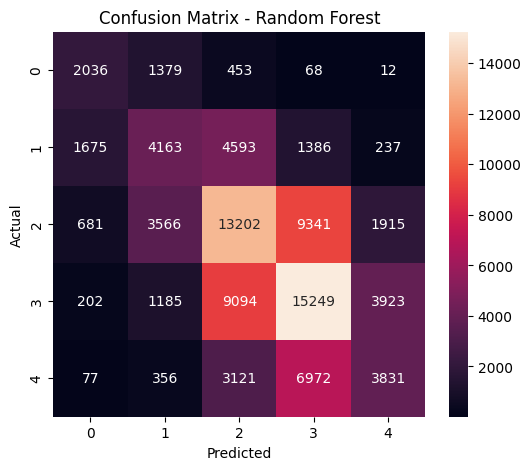

In [73]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Feature Importance

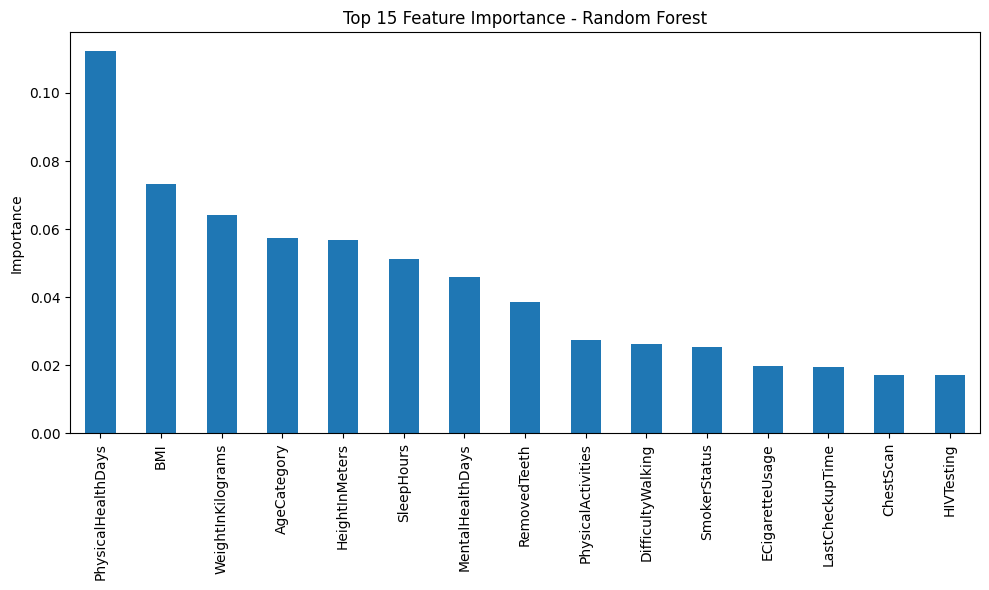

In [74]:
importances = rf.feature_importances_
feat_importance = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_importance[:15].plot(kind='bar')
plt.title("Top 15 Feature Importance - Random Forest")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

Perbandingan dengan Baseline

In [75]:
print(f"  Logistic Regression : {acc:.4f}")
print(f"  Random Forest       : {acc_rf:.4f}")

  Logistic Regression : 0.3678
  Random Forest       : 0.4338


## Hyperparameter Tuning

In [79]:
from sklearn.model_selection import RandomizedSearchCV

rf_param_dist = {
    'n_estimators'     : [100, 200],
    'max_depth'        : [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf' : [1, 2],
    'max_features'     : ['sqrt']
}

In [80]:
rf_base = RandomForestClassifier(
    random_state=42,
    n_jobs=2
)

In [81]:
rf_random = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=3,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=2
)

In [82]:
rf_random.fit(X_train_sm, y_train_sm)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [10, 20, ...], 'max_features': ['sqrt'], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionch

In [83]:
print("\nBest params Random Forest:")
print(rf_random.best_params_)
print(f"Best CV F1-Weighted: {rf_random.best_score_:.4f}")


Best params Random Forest:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
Best CV F1-Weighted: 0.6278


## Training ulang

In [84]:
rf_best = rf_random.best_estimator_

In [85]:
y_pred_rf_tuned = rf_best.predict(X_test)

In [86]:
acc_rf_tuned = accuracy_score(y_test, y_pred_rf_tuned)
print("Accuracy RF (Tuned):", acc_rf_tuned)

Accuracy RF (Tuned): 0.43776277376376566


In [87]:
print(classification_report(y_test, y_pred_rf_tuned,
      target_names=['Poor','Fair','Good','Very Good','Excellent']))

              precision    recall  f1-score   support

        Poor       0.44      0.52      0.48      3948
        Fair       0.39      0.34      0.37     12054
        Good       0.44      0.46      0.45     28705
   Very Good       0.46      0.52      0.49     29653
   Excellent       0.39      0.27      0.32     14357

    accuracy                           0.44     88717
   macro avg       0.43      0.42      0.42     88717
weighted avg       0.43      0.44      0.43     88717



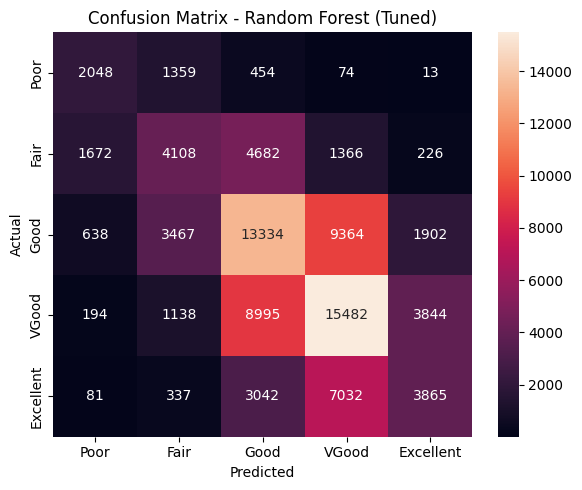

In [88]:
cm_rf_tuned = confusion_matrix(y_test, y_pred_rf_tuned)

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf_tuned, annot=True, fmt='d',
            xticklabels=['Poor','Fair','Good','VGood','Excellent'],
            yticklabels=['Poor','Fair','Good','VGood','Excellent'])
plt.title("Confusion Matrix - Random Forest (Tuned)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout(); plt.show()

# XGBoost

In [89]:
import importlib.util

spec = importlib.util.find_spec("xgboost.compat")
print(spec.origin)

/opt/homebrew/lib/python3.11/site-packages/xgboost/compat.py


In [90]:
import sys

!{sys.executable} -m pip install --force-reinstall pandas==2.2.2
!{sys.executable} -m pip install --force-reinstall numpy==1.26.4
!{sys.executable} -m pip install --force-reinstall scipy==1.13.1
!{sys.executable} -m pip install --force-reinstall xgboost==2.1.4

  Using cached pandas-2.2.2-cp311-cp311-macosx_11_0_arm64.whl.metadata (19 kB)
  Using cached numpy-2.4.6-cp311-cp311-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached pytz-2026.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
Using cached pandas-2.2.2-cp311-cp311-macosx_11_0_arm64.whl (11.3 MB)
Using cached numpy-2.4.6-cp311-cp311-macosx_14_0_arm64.whl (5.5 MB)
Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl (229 kB)
Using cached pytz-2026.2-py2.py3-none-any.whl (510 kB)
Using cached six-1.17.0-py2.py3-none-any.whl (11 kB)
Using cached tzdata-2026.2-py2.py3-none-any.whl (349 kB)
  Attempting uninstall: pytz
    Found existing installation: pytz 2026.2
    Uninstalling pytz-2026.2:
      Successfully uninstalled pytz-2026.2
  Attempting uninstall: tzdata
    Found 

In [91]:
import pandas as pd
import numpy as np
import scipy

print("pandas:", pd.__version__)
print("numpy :", np.__version__)
print("scipy :", scipy.__version__)

pandas: 2.2.2
numpy : 2.4.6
scipy : 1.17.1


In [92]:
import pandas as pd
import numpy as np
import scipy

print("pandas:", pd.__version__)
print("numpy :", np.__version__)
print("scipy :", scipy.__version__)

pandas: 2.2.2
numpy : 2.4.6
scipy : 1.17.1


In [93]:
import importlib.util
print(importlib.util.find_spec("xgboost.compat").origin)

/opt/homebrew/lib/python3.11/site-packages/xgboost/compat.py


In [94]:
from xgboost.compat import PANDAS_INSTALLED
print(PANDAS_INSTALLED)

True


In [95]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

inisaialisasi model

In [96]:
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)


training model

In [97]:
xgb.fit(X_train_sm, y_train_sm)

/opt/homebrew/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [00:17:20] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


prediksi

In [98]:
y_pred_xgb = xgb.predict(X_test)

accuracy

In [99]:
acc_xgb = accuracy_score(y_test, y_pred_xgb)
print("Accuracy XGBoost:", acc_xgb)

Accuracy XGBoost: 0.43865324571389924


classification report

In [100]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.42      0.61      0.49      3948
           1       0.41      0.30      0.34     12054
           2       0.45      0.44      0.44     28705
           3       0.47      0.50      0.48     29653
           4       0.38      0.39      0.39     14357

    accuracy                           0.44     88717
   macro avg       0.43      0.45      0.43     88717
weighted avg       0.44      0.44      0.44     88717



confusion matrix

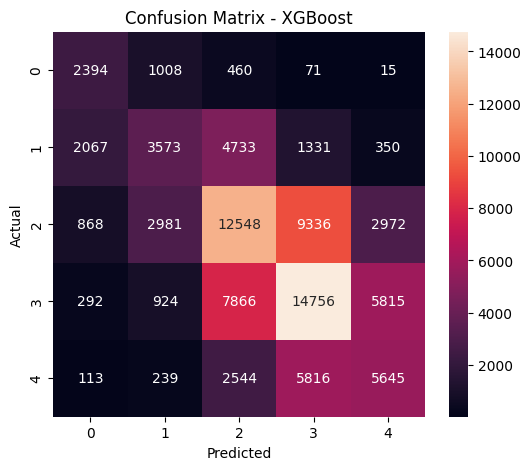

In [101]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d')
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


feature important

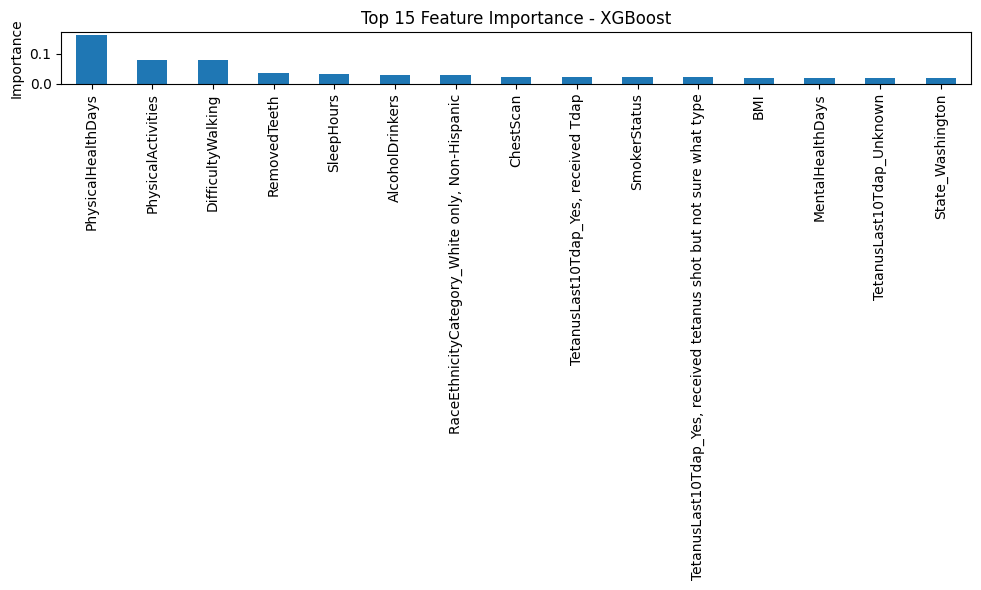

In [102]:
importances_xgb = xgb.feature_importances_
feat_importance_xgb = pd.Series(importances_xgb, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_importance_xgb[:15].plot(kind='bar')
plt.title("Top 15 Feature Importance - XGBoost")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

## Hyperparameter Tuning

XGBoost (RandomizedSearchCV)

In [103]:
from xgboost import XGBClassifier

xgb_param_dist = {
    'n_estimators' : [100, 200],
    'max_depth'    : [3, 5, 6],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample'    : [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'min_child_weight': [1, 3]
}


In [ ]:
xgb_base = XGBClassifier(
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=2,        # dari -1 → 1
    verbosity=0
)

In [107]:
xgb_random = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_dist,
    n_iter=10,        # dari 20 → 5
    cv=3,            # dari 3 → 2
    scoring='f1_weighted',
    random_state=42,
    n_jobs=2     # dari -1 → 1
)

In [108]:
xgb_random.fit(X_train_sm, y_train_sm)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...state=42, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.05, 0.1, ...], 'max_depth': [3, 5, ...], 'min_child_weight': [1, 3], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.

In [109]:
print("\nBest params XGBoost:")
print(xgb_random.best_params_)
print(f"Best CV F1-Weighted: {xgb_random.best_score_:.4f}")


Best params XGBoost:
{'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.2, 'colsample_bytree': 0.8}
Best CV F1-Weighted: 0.5219


## Training ulang

In [110]:
xgb_best = xgb_random.best_estimator_

In [111]:
y_pred_xgb_tuned = xgb_best.predict(X_test)

In [112]:
acc_xgb_tuned = accuracy_score(y_test, y_pred_xgb_tuned)
print("Accuracy XGBoost (Tuned + SMOTE):", acc_xgb_tuned)

Accuracy XGBoost (Tuned + SMOTE): 0.4531375046496162


In [113]:
print(classification_report(y_test, y_pred_xgb_tuned,
      target_names=['Poor','Fair','Good','Very Good','Excellent']))

              precision    recall  f1-score   support

        Poor       0.48      0.49      0.48      3948
        Fair       0.44      0.30      0.35     12054
        Good       0.44      0.48      0.46     28705
   Very Good       0.47      0.57      0.51     29653
   Excellent       0.43      0.27      0.33     14357

    accuracy                           0.45     88717
   macro avg       0.45      0.42      0.43     88717
weighted avg       0.45      0.45      0.44     88717



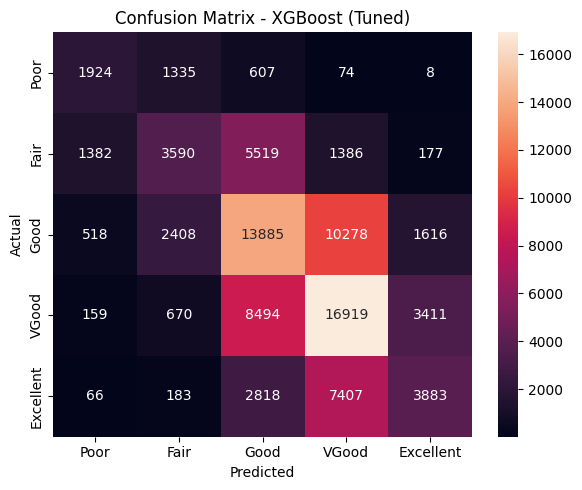

In [114]:
cm_xgb_tuned = confusion_matrix(y_test, y_pred_xgb_tuned)

plt.figure(figsize=(6,5))
sns.heatmap(cm_xgb_tuned, annot=True, fmt='d',
            xticklabels=['Poor','Fair','Good','VGood','Excellent'],
            yticklabels=['Poor','Fair','Good','VGood','Excellent'])
plt.title("Confusion Matrix - XGBoost (Tuned)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout(); plt.show()

# Perbandingan semua model

In [115]:
print(f"  Logistic Regression : {acc:.4f}")
print(f"  Random Forest       : {acc_rf:.4f}")
print(f"  XGBoost             : {acc_xgb:.4f}")

  Logistic Regression : 0.3678
  Random Forest       : 0.4338
  XGBoost             : 0.4387
